# Introduction

Clustering is an unsupervised learning technique that aims to group a set of data points into subsets (or "clusters") such that data points within the same group are more similar to each other than to those in other groups. Clustering has a variety of applications in extracting information from data without labels. For example, companies cluster customers based on their characteristics, like purchasing behaviors, to make better market campaigns, to set pricing strategies to make more profit, etc.

There are various types of clustering algorithms, each with its strengths and weaknesses. Here are some common types:

* **K-Means**: The algorithm partitions a dataset into a predefined number of clusters, denoted by k, where each cluster is represented by its center, called the centroid.

* **Hierarchical Clustering**: These algorithm that organizes data into a tree-like structure of nested clusters. The process can be visualized as a dendrogram, which displays how clusters are merged or split at each step.

* **Density Based Clustering**: These algorithms group data points based on regions of high density separated by regions of low density.

In these notebook we will only be looking at a K-Means clustering algorithm.


## K-Means Clustering

K-means is a popular unsupervised machine learning algorithm used for clustering data into groups based on similarity. The algorithm partitions a dataset into a predefined number of clusters, denoted by k, where each cluster is represented by its center, called the centroid. The goal of K-means is to minimize the sum of squared distances between each data point and its assigned centroid, resulting in clusters where members are as similar as possible to each other and as different as possible from those in other clusters.

### How the algorithm works
K-Means goes through the following steps when trying to group data into clusters:

1. **Initialization**: Choose the number of clusters *k*, and randomly select *k* initial centroids from the data.

2. **Assignment**: Assign each data point to the nearest centroid based on a distance metric.

3. **Update**: Recalculate the centroids as the mean of all data points assigned to each cluster.

4. **Iteration**: Repeat the assignment and update steps until the centroids no longer change significantly or a set number of iterations is reached.

### Limitation of K-Means

* **Sensitivity to Initial Centroids**: The initial random placement of centroids can influence the final clustering result. Running the algorithm multiple times with different initializations can help mitigate this.

* **Assumes Spherical Clusters**: K-Means tends to form roughly spherical clusters and may struggle with clusters of irregular shapes.

* **Requires Specifying K**: You need to decide on the number of clusters, *k* beforehand.

### Implementing K-Means with Scikit-learn


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

In [2]:
# Generate random data containing 2 groups

np.random.seed(42)

x = np.random.randn(100, 2) + np.array([0, 2])
y = np.random.randn(100, 2) + np.array([-2, -4])

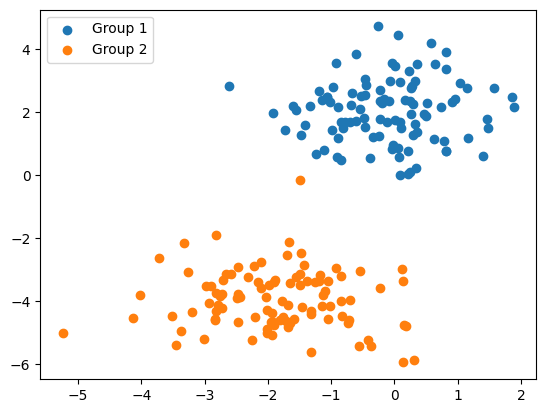

In [3]:
plt.scatter(x[:, 0], x[:, 1], label="Group 1")
plt.scatter(y[:, 0], y[:, 1], label="Group 2")
plt.legend();

In [4]:
X = np.vstack([x, y])  # Concatenate the generated data vertically

kmeans = KMeans(5, random_state=42)  # Instantiate k-means
kmeans.fit(X)  # Fit the model

,n_clusters,5
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [5]:
# Get cluster labels

labels = kmeans.predict(X)

In [6]:
# Insert the data into a DataFrame

clustered_data = pd.DataFrame(X, columns=["f1",  "f2"]).assign(cluster=labels)
clustered_data.head()

,f1,f2,cluster
0,0.496714,1.861736,0
1,0.647689,3.523030,0
2,-0.234153,1.765863,2
3,1.579213,2.767435,0
4,-0.469474,2.542560,0


In [7]:
kmeans.cluster_centers_

array([[ 0.30457013,  2.81623067],
       [-1.27801263, -4.76810159],
       [-0.4776256 ,  1.36651043],
       [-1.33318453, -3.29131735],
       [-3.01744972, -3.8807987 ]])

In [1]:
sns.scatterplot(clustered_data, x="f1", y="f2", hue="cluster", palette="dark")
sns.scatterplot(
    x=kmeans.cluster_centers_[:, 0],
    y=kmeans.cluster_centers_[:, 1],
    color="black",
    marker="X",
    label="Cluster Center",
)
plt.legend(loc="upper left");

NameError: name 'sns' is not defined

Plot above shows that the K-Means algorithm performed well in grouping the data. Next we look at metrics for evaluating the performance of clustering models

## Evaluating the K-Means Model

Since clustering is unsupervised, we don't have pre-labeled data to directly compare our results against. However, we can use internal evaluation metrics to assess the quality of our clusters.

### Inertia

Inertia measures how "tight" or "compact" the clusters are. It's the sum of the squared distances between each data point and its assigned cluster center. Lower inertia generally indicates better clustering, as it means data points are closer to their respective center. The major limitation of inertia is that it always decreases as you increase the number of clusters *K*. Therefore, a *K* equal to the number of data points would result in zero inertia, but that's not useful clustering. Therefore, it's not sufficient on its own to determine the optimal *K*.

The inertia for the trained model can be accessed via the `intertia_` attribute.

In [9]:
# Check the inertia of the model

print("Inertia:", kmeans.inertia_)

Inertia: 187.74605221050155


The model has an intertia of approximately 357. This tells us that the average distance between the samples and their respective cluster 357.

### Silhouette Score

The Silhouette Score measures how similar an object is to its own cluster (cohesion) compared to other clusters (separation). It ranges from *-1* to *1*. A score close to *1* indicates that the data point is well-matched to its own cluster and poorly matched to neighboring clusters (good clustering). A score around *0* indicates that the data point is on or very close to the decision boundary between two neighboring clusters. A score close to *-1* indicates that the data point is probably assigned to the wrong cluster.

We can use the `silhouette_score` function from sklearn to compute the silhouette score pf the model output. The function takes the data points and their cluster labels and returns the average silhouette score of of the data points.

In [10]:
from sklearn.metrics import silhouette_score

In [11]:
print("Silhouette score:", silhouette_score(X, labels))

Silhouette score: 0.3450849492193527


This tells us that, on average the silhouette score of a sample is approximately 0.73. This indicates that the data points are well matched to the cluster they are assigned to.

## Finding the Optimal Number of Clusters

Choosing the "right" *K* for K-Means is crucial and can significantly impact the quality of our results. Here are two popular methods we can use to find the optimal number of clusters:

*  **The Elbow Method**: This method uses the Inertia. As you increase the number of clusters (K), the inertia will naturally decrease because data points will be closer to their centroids. However, at some point, adding more clusters provides diminishing returns in terms of reducing inertia. The method involves the following steps:

    1. Run the K-Means algorithm for a range of K values (e.g., from 1 to 10).

    2. Calculate the Inertia for each K.

    3. Plot Inertia against K.

    4. Look for the "elbow" point on the graph. This is the point where the rate of decrease in inertia sharply changes, forming an "elbow" shape. The K value at this elbow is often considered the optimal number of clusters.

*  **Silhouette Analysis**: This method uses the Silhouette Score to evaluate the quality of clustering for different K values. The method involves the following steps:

    1. Run the K-Means algorithm for a range of K values.

    2. Calculate the average Silhouette Score for each K.

    3. Plot the average Silhouette Score against K.

    4. The K value that yields the highest average Silhouette Score is generally considered the optimal number of clusters, as it indicates well-separated and cohesive clusters.

Both the Elbow Method and Silhouette Analysis provide guidance, but the "optimal" K can also depend on domain knowledge and the specific goals of your clustering task. Sometimes, there isn't a perfectly clear "elbow" or a single highest Silhouette score, requiring a more subjective decision based on the problem context.

### Determining the optimal number of clusters with the elbow method

In [12]:
# Run the algorithm for different values of K from 2 to 100.

inertias = []
n_clusters = range(2, 101)

for n_cluster in n_clusters:
    _kmeans = KMeans(n_cluster, random_state=42)
    _kmeans.fit(X)
    _inertia = _kmeans.inertia_

    inertias.append(_inertia)

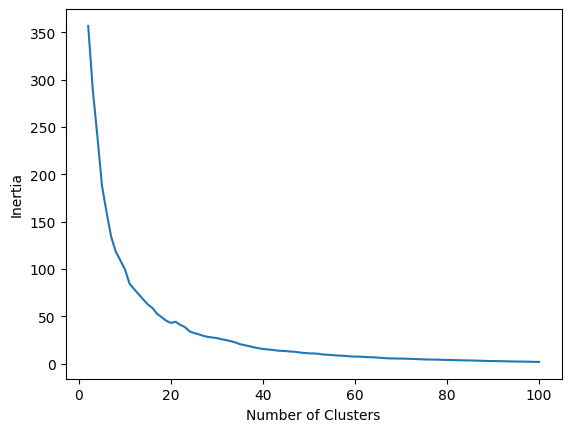

In [13]:
plt.plot(n_clusters, inertias)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia");

From the figure above, the elbow point seems to be around 20 clusters. Lets retrain the model with 20 clusters and evaluate the result.

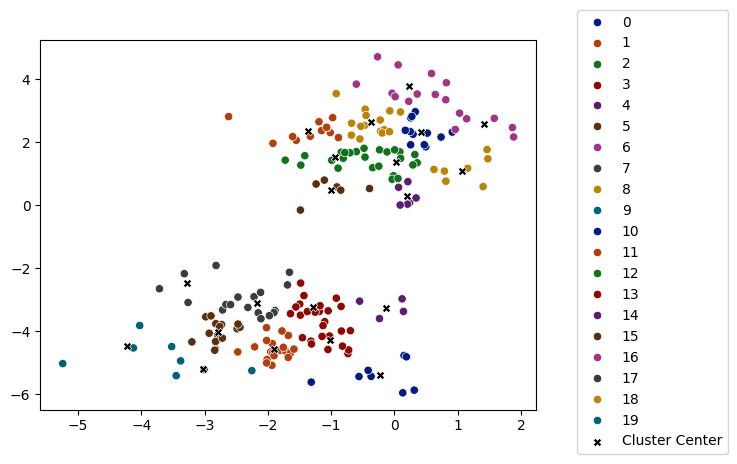

In [14]:
kmeans = KMeans(20, random_state=42)
kmeans.fit(X)

labels = kmeans.predict(X)

sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=labels, palette="dark")
sns.scatterplot(
    x=kmeans.cluster_centers_[:, 0],
    y=kmeans.cluster_centers_[:, 1],
    color="black",
    marker="X",
    label="Cluster Center",
)
plt.legend(loc="upper right", bbox_to_anchor=(1.4, 1.1));

### Determining the optimal number of clusters with Silhouette score

In [15]:
# Run the algorithm for different values of K from 2 to 100.

sh_scores = []
n_clusters = range(2, 101)

for n_cluster in n_clusters:
    _kmeans = KMeans(n_cluster, random_state=42)
    _kmeans.fit(X)
    sh_score = silhouette_score(X, _kmeans.predict(X))

    sh_scores.append(sh_score)

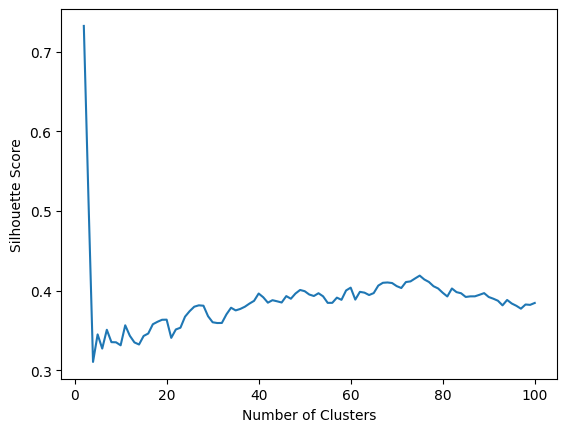

In [16]:
plt.plot(n_clusters, sh_scores)
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score");

The figure above shows that the optimal number of clusters is 2. The is quite different from what was observed on the elbow curve plot. This further reinforces that fact that determining the optimal number of clusters can also depend on other factors such as the domain knowledge or the specific goal of the clustering task.